# Random Forest Model

In [1]:
# Import libraries
import warnings;

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc

warnings.filterwarnings("ignore")
sns.set()
sns.set_theme(style="whitegrid")

## Dataset

In [3]:
# Import dataset: dataset_logreg
df = pd.read_csv('dataset_tree.csv')
df = df[['duration_latest', 'age', 'evr_quarterly', 'cci_monthly', 'days_last_campaign', 'month_last_contacted', 'cpi_monthly', 'Response']]
df.head()

,duration_latest,age,evr_quarterly,cci_monthly,days_last_campaign,month_last_contacted,cpi_monthly,Response
0,8.770292,57,-1.8,-46.2,0,0.335429,92.893,0
1,8.227745,55,1.1,-36.4,0,0.335429,93.994,0
2,5.142826,33,-1.8,-46.2,0,0.335429,92.893,0
3,8.678318,36,1.4,-41.8,0,0.129697,94.465,0
4,7.418466,27,1.4,-42.7,0,0.175015,93.918,0


In [4]:
# Define features and target variable
X = df.drop('Response', axis=1)
y = df[['Response']]

# Ensure the target variable is binary
y = y.astype('int')

# Check the shape of the features and target variable
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Features shape: (34997, 7)
Target shape: (34997, 1)


## Modeling

In [5]:
# Hyperparameters
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Model training
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_cv = RandomizedSearchCV(
            estimator=rf_model, 
            param_distributions=params, 
            cv=5, 
            scoring='precision'
        )

rf_cv.fit(X_train, y_train.values.ravel())

# Best parameters
print("Best parameters found: ", rf_cv.best_params_)

# Best score
print("Best score: ", rf_cv.best_score_)

# Best estimator
best_rf_model = rf_cv.best_estimator_

Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
Best score:  0.6537569594733637


## Evaluation

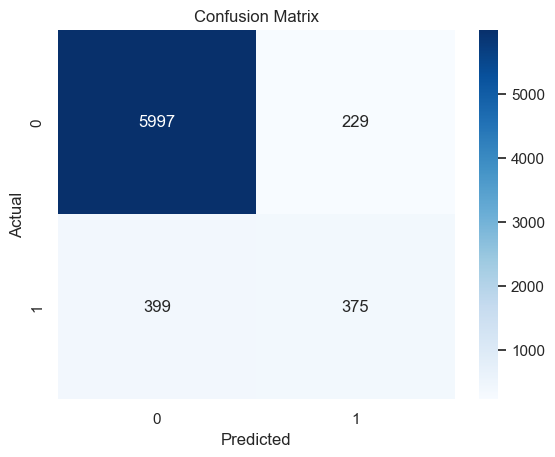

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6226
           1       0.62      0.48      0.54       774

    accuracy                           0.91      7000
   macro avg       0.78      0.72      0.75      7000
weighted avg       0.90      0.91      0.91      7000

ROC AUC Score: 0.9346
Accuracy Score: 0.9103


In [6]:
# Making predictions
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

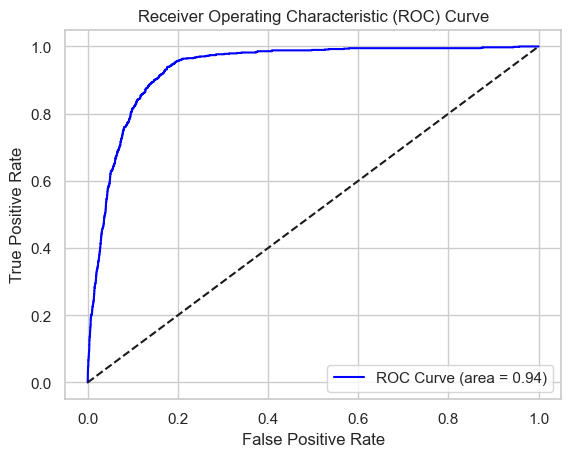

In [12]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='blue', label='ROC Curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='k', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### PR AUC

In [7]:
# Setup y_true and y_scores
y_true = y_test
y_scores = best_rf_model.predict_proba(X_test)[:,1] # run this if using logreg

# Option 1
pr_auc = average_precision_score(y_true, y_scores)

# Option 2
precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc_curve = auc(recall, precision)

print(f'Average Precision (PR AUC): {pr_auc}')
print(f'PR Curve AUC: {pr_auc_curve}')

Average Precision (PR AUC): 0.5944781796905829
PR Curve AUC: 0.5934344854900391


## Profitability Analysis

### Initial profitability caused by the model's output

In [8]:
# From the net profit estimates provided by the Finance team,
## High risk band:
risk_dist_high = 0.10
tp_gain_high = 285
fp_cost_high = 300
fn_cost_high = tp_gain_high # the cost of not predicting buyers correctly is equivalent to the supposed gain from a true positive

## Medium risk band:
risk_dist_mid = 0.25
tp_gain_mid = 705
fp_cost_mid = 300
fn_cost_mid = tp_gain_mid

## Low risk band:
risk_dist_low = 0.65
tp_gain_low = 1225
fp_cost_low = 300
fn_cost_low = tp_gain_low

# Scaling confusion matrix results to the new list of 10,000 records
## From the confusion matrix:
TN_orig = cm[0,0]
FP_orig = cm[0,1]
FN_orig = cm[1,0]
TP_orig = cm[1,1]

## Confusion matrix rates based on 7,000 records from test dataset
TN_rate = TN_orig / 7000
FP_rate = FP_orig / 7000
FN_rate = FN_orig / 7000
TP_rate = TP_orig / 7000

## Scaling to 10,000 records for each band
### High risk band:
TN_new_high = TN_rate * 10000 * risk_dist_high
FP_new_high = FP_rate * 10000 * risk_dist_high
FN_new_high = FN_rate * 10000 * risk_dist_high
TP_new_high = TP_rate * 10000 * risk_dist_high

### Medium risk band:
TN_new_mid = TN_rate * 10000 * risk_dist_mid
FP_new_mid = FP_rate * 10000 * risk_dist_mid
FN_new_mid = FN_rate * 10000 * risk_dist_mid
TP_new_mid = TP_rate * 10000 * risk_dist_mid

### Low risk band:
TN_new_low = TN_rate * 10000 * risk_dist_low
FP_new_low = FP_rate * 10000 * risk_dist_low
FN_new_low = FN_rate * 10000 * risk_dist_low
TP_new_low = TP_rate * 10000 * risk_dist_low

# Profit computation
profit_contri_high = (TP_new_high * tp_gain_high) - (FP_new_high * fp_cost_high) - (FN_new_high * fn_cost_high)
profit_contri_mid = (TP_new_mid * tp_gain_mid) - (FP_new_mid * fp_cost_mid) - (FN_new_mid * fn_cost_mid)
profit_contri_low = (TP_new_low * tp_gain_low) - (FP_new_low * fp_cost_low) - (FN_new_low * fn_cost_low)

total_profit = profit_contri_high + profit_contri_mid + profit_contri_low

print(f'Total profit: ${total_profit.round(2)}')

Total profit: $-132462.86


In [9]:
# Setting the y_prob_best from the best_model which is equal to y_scores
y_prob_best = y_scores

### High-Risk Bands

Best threshold: 0.367
Best profit: -40920


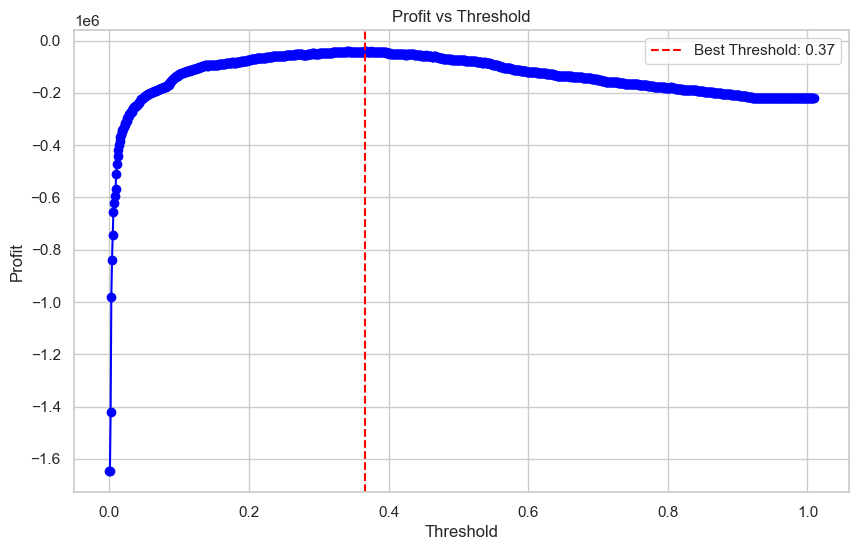

In [10]:
# Setting up thresholds and profit placeholder
thresholds = np.arange(0.0, 1.01, 0.001)
profits_high = []
tp_at_best_high = []
fn_at_best_high = []

# Defining a profit function for high-risk customers
for t in thresholds:
    y_pred_thresholded = (y_prob_best >= t).astype(int)
    cm_thresholded = confusion_matrix(y_test, y_pred_thresholded)
    
    # Assuming profit calculation based on confusion matrix
    # Example: Profit = (TP * profit_per_positive) - (FP * cost_per_false_positive) - (FN * cost_per_false_negative)
    tp_gain = 285  # Example profit for true positives
    fp_cost = 300  # Example cost for false positives
    fn_cost = tp_gain  # Example cost for false negatives
    
    TP = cm_thresholded[1, 1]
    FP = cm_thresholded[0, 1]
    FN = cm_thresholded[1, 0]
    
    profit = (TP * tp_gain) - (FP * fp_cost) - (FN * fn_cost)
    profits_high.append(profit)
    tp_at_best_high.append(TP)
    fn_at_best_high.append(FN)

best_idx_high = np.argmax(profits_high)
best_threshold_high = thresholds[best_idx_high]
best_profit = profits_high[best_idx_high]

print(f'Best threshold: {best_threshold_high}')
print(f'Best profit: {best_profit}')

# Plotting profit vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits_high, marker='o', color='blue')
plt.axvline(x=best_threshold_high, color='red', linestyle='--', label=f'Best Threshold: {best_threshold_high:.2f}')
plt.title('Profit vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
tp_at_best_high = tp_at_best_high[best_idx_high] * 285
fn_at_best_high = fn_at_best_high[best_idx_high] * 285

### Medium-Risk Bands

Best threshold: 0.137
Best profit: 156900


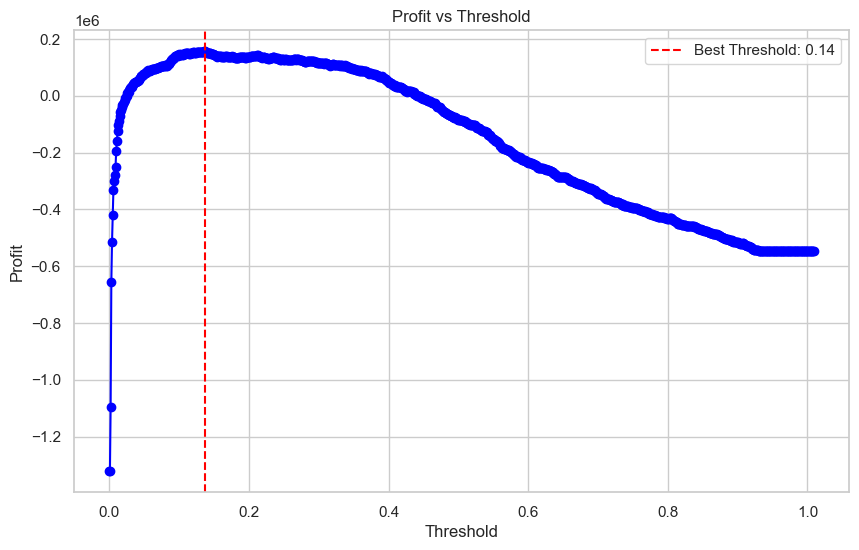

In [12]:
# Setting up thresholds and profit placeholder
thresholds = np.arange(0.0, 1.01, 0.001)
profits_mid = []
tp_at_best_mid = []
fn_at_best_mid = []

# Defining a profit function for high-risk customers
for t in thresholds:
    y_pred_thresholded = (y_prob_best >= t).astype(int)
    cm_thresholded = confusion_matrix(y_test, y_pred_thresholded)
    
    # Assuming profit calculation based on confusion matrix
    # Example: Profit = (TP * profit_per_positive) - (FP * cost_per_false_positive) - (FN * cost_per_false_negative)
    tp_gain = 705  # Example profit for true positives
    fp_cost = 300  # Example cost for false positives
    fn_cost = tp_gain  # Example cost for false negatives
    
    TP = cm_thresholded[1, 1]
    FP = cm_thresholded[0, 1]
    FN = cm_thresholded[1, 0]
    
    profit = (TP * tp_gain) - (FP * fp_cost) - (FN * fn_cost)
    profits_mid.append(profit)
    tp_at_best_mid.append(TP)
    fn_at_best_mid.append(FN)

best_idx_mid = np.argmax(profits_mid)
best_threshold_mid = thresholds[best_idx_mid]
best_profit = profits_mid[best_idx_mid]

print(f'Best threshold: {best_threshold_mid}')
print(f'Best profit: {best_profit}')

# Plotting profit vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits_mid, marker='o', color='blue')
plt.axvline(x=best_threshold_mid, color='red', linestyle='--', label=f'Best Threshold: {best_threshold_mid:.2f}')
plt.title('Profit vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
tp_at_best_mid = tp_at_best_mid[best_idx_mid] * 705
fn_at_best_mid = fn_at_best_mid[best_idx_mid] * 705

### Low-Risk Bands

Best threshold: 0.097
Best profit: 486300


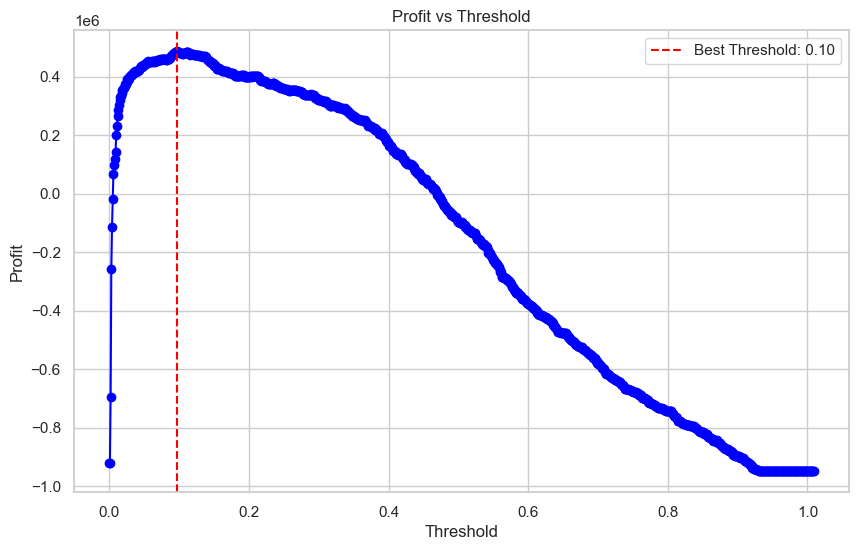

In [14]:
# Setting up thresholds and profit placeholder
thresholds = np.arange(0.0, 1.01, 0.001)
profits_low = []
tp_at_best_low = []
fn_at_best_low = []

# Defining a profit function for high-risk customers
for t in thresholds:
    y_pred_thresholded = (y_prob_best >= t).astype(int)
    cm_thresholded = confusion_matrix(y_test, y_pred_thresholded)
    
    # Assuming profit calculation based on confusion matrix
    # Example: Profit = (TP * profit_per_positive) - (FP * cost_per_false_positive) - (FN * cost_per_false_negative)
    tp_gain = 1225  # Example profit for true positives
    fp_cost = 300  # Example cost for false positives
    fn_cost = tp_gain  # Example cost for false negatives
    
    TP = cm_thresholded[1, 1]
    FP = cm_thresholded[0, 1]
    FN = cm_thresholded[1, 0]
    
    profit = (TP * tp_gain) - (FP * fp_cost) - (FN * fn_cost)
    profits_low.append(profit)
    tp_at_best_low.append(TP)
    fn_at_best_low.append(FN)

best_idx_low = np.argmax(profits_low)
best_threshold_low = thresholds[best_idx_low]
best_profit = profits_low[best_idx_low]

print(f'Best threshold: {best_threshold_low}')
print(f'Best profit: {best_profit}')

# Plotting profit vs threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits_low, marker='o', color='blue')
plt.axvline(x=best_threshold_low, color='red', linestyle='--', label=f'Best Threshold: {best_threshold_low:.2f}')
plt.title('Profit vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
tp_at_best_low = tp_at_best_low[best_idx_low] * 1225
fn_at_best_low = fn_at_best_low[best_idx_low] * 1225

### Summing up the contributions of each risk band to the overall profitability

In [16]:
#Profitability summary for each risk band
profitability_summary = {
    'High Risk': {
        'Best Threshold': best_threshold_high,
        'Best Profit': profits_high[best_idx_high]
    },
    'Mid Risk': {
        'Best Threshold': best_threshold_mid,
        'Best Profit': profits_mid[best_idx_mid]
    },
    'Low Risk': {
        'Best Threshold': best_threshold_low,
        'Best Profit': profits_low[best_idx_low]
    }
}

print("\nProfitability Summary:")
for risk_band, metrics in profitability_summary.items():
    print(f"{risk_band} - Best Threshold: {metrics['Best Threshold']:.2f}, Best Profit: {metrics['Best Profit']:.2f}")  


Profitability Summary:
High Risk - Best Threshold: 0.37, Best Profit: -40920.00
Mid Risk - Best Threshold: 0.14, Best Profit: 156900.00
Low Risk - Best Threshold: 0.10, Best Profit: 486300.00


In [17]:
# Total Profitability Calculation
total_profit = (
    profitability_summary['High Risk']['Best Profit'] +
    profitability_summary['Mid Risk']['Best Profit'] +
    profitability_summary['Low Risk']['Best Profit']
)

if total_profit > 0:
    print(f"\nTotal Profitability: ${total_profit:.2f}")
    print('The model returns a profitable results to the company!')
elif total_profit < 0:
    print(f"\nTotal Profitability: {total_profit:.2f}")
    print('The model returns a losses to the company!')
else:
    print(f"\nTotal Profitability: {total_profit:.2f}")
    print("The model cause no effect to the company's profitability!")


Total Profitability: $602280.00
The model returns a profitable results to the company!


In [18]:
# Expected net profit we stand on intended phone calls
tp_total_profit = tp_at_best_high + tp_at_best_mid + tp_at_best_low
print(f'The expected net profit from all calls made based on the model outcomes: ${tp_total_profit}')

# Expected net loss in opportunity due to misclassified customers
fn_total_loss = fn_at_best_high + fn_at_best_mid + fn_at_best_low
print(f'The expected net lost opportunities due to wrong calls: ${fn_total_loss}')

The expected net profit from all calls made based on the model outcomes: $1516845
The expected net lost opportunities due to wrong calls: $197565
